# Part A: U.S. unemployment rate time-series analysis

This notebook analyzes the monthly U.S. unemployment-rate series in `data/US_UR.csv` according to `pt_a_description.md`. The workflow follows the course reference, *Introduction to Time Series and Forecasting*: first make the series stationary, then fit ARMA models to the stationary series, and finally use linear forecasts with forecast-error diagnostics.

In [23]:
# Core libraries
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Load and clean the data

The file has two columns: a monthly date and the unemployment rate. The raw CSV contains blank trailing rows, so those rows are removed. Dates are parsed as day-month-year and the series is stored with a monthly-start frequency.

In [ ]:
raw = pd.read_csv("data/US_UR.csv")
df = raw.dropna().copy()
df["date"] = pd.to_datetime(df["Yearmon"], format="%d-%m-%Y")
df = df.rename(columns={"US UnemploymentRate": "unemployment_rate"})
df = df[df["date"] < "2020-01-01"]

y = df.set_index("date")["unemployment_rate"].asfreq("MS")

summary = pd.Series({
    "raw_rows": len(raw),
    "usable_observations": len(y),
    "missing_months_after_cleaning": int(y.isna().sum()),
    "start": y.index.min().strftime("%Y-%m"),
    "end": y.index.max().strftime("%Y-%m"),
    "minimum_rate": y.min(),
    "maximum_rate": y.max(),
    "mean_rate": y.mean(),
})
summary

raw_rows                            1499
usable_observations                  260
missing_months_after_cleaning          0
start                            2000-01
end                              2021-08
minimum_rate                      3.5000
maximum_rate                     14.8000
mean_rate                         5.9835
dtype: object

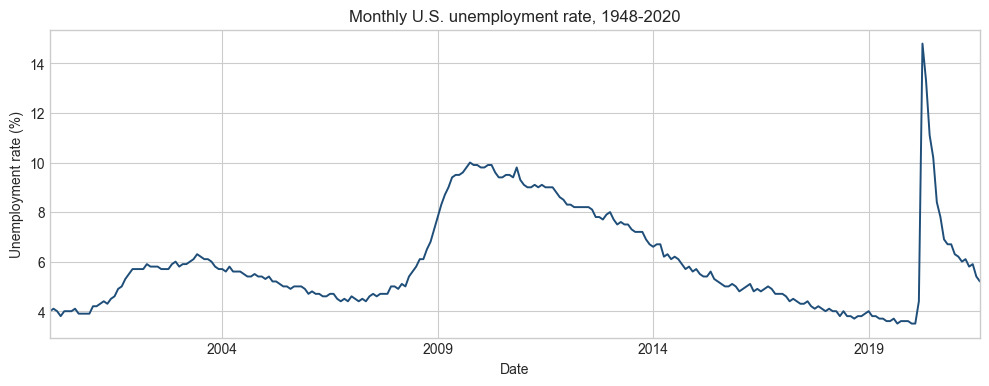

In [33]:
fig, ax = plt.subplots(figsize=(12, 4))
y.plot(ax=ax, color="#1f4e79", linewidth=1.4)
ax.set_title("Monthly U.S. unemployment rate, 1948-2020")
ax.set_xlabel("Date")
ax.set_ylabel("Unemployment rate (%)")
plt.show()

## 2. Stationarity and transformation

The reference text treats ARMA models as models for weakly stationary series. The unemployment-rate level is persistent and affected by business-cycle regimes, so the stationary working series is the first difference

$$x_t = y_t - y_{t-1},$$

where $y_t$ is the unemployment rate at month $t$. No deterministic seasonal component is removed because the monthly means are very similar; the CSV also appears to contain an already seasonally adjusted unemployment-rate series. Thus the explicit cleaning step used for modeling is first differencing.

In [26]:
def stationarity_table(series, name):
    series = series.dropna()
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    return pd.Series({
        "series": name,
        "mean": series.mean(),
        "std": series.std(),
        "ADF statistic": adf_stat,
        "ADF p-value": adf_p,
        "KPSS statistic": kpss_stat,
        "KPSS p-value": kpss_p,
    })

x = y.diff().dropna()
tests = pd.DataFrame([
    stationarity_table(y, "level y_t"),
    stationarity_table(x, "first difference x_t"),
])

monthly_means = y.groupby(y.index.month).mean().rename("monthly_mean")
display(tests)
display(monthly_means.to_frame().T)

,series,mean,std,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,level y_t,5.9835,1.9524,-3.0153,0.0335,0.2977,0.1000
1,first difference x_t,0.0046,0.7046,-12.4483,0.0000,0.0625,0.1000


date,1,2,3,4,5,6,7,8,9,10,11,12
monthly_mean,5.8000,5.7955,5.8227,6.3045,6.2136,6.1318,6.0545,5.9773,5.9429,5.9143,5.9190,5.9143


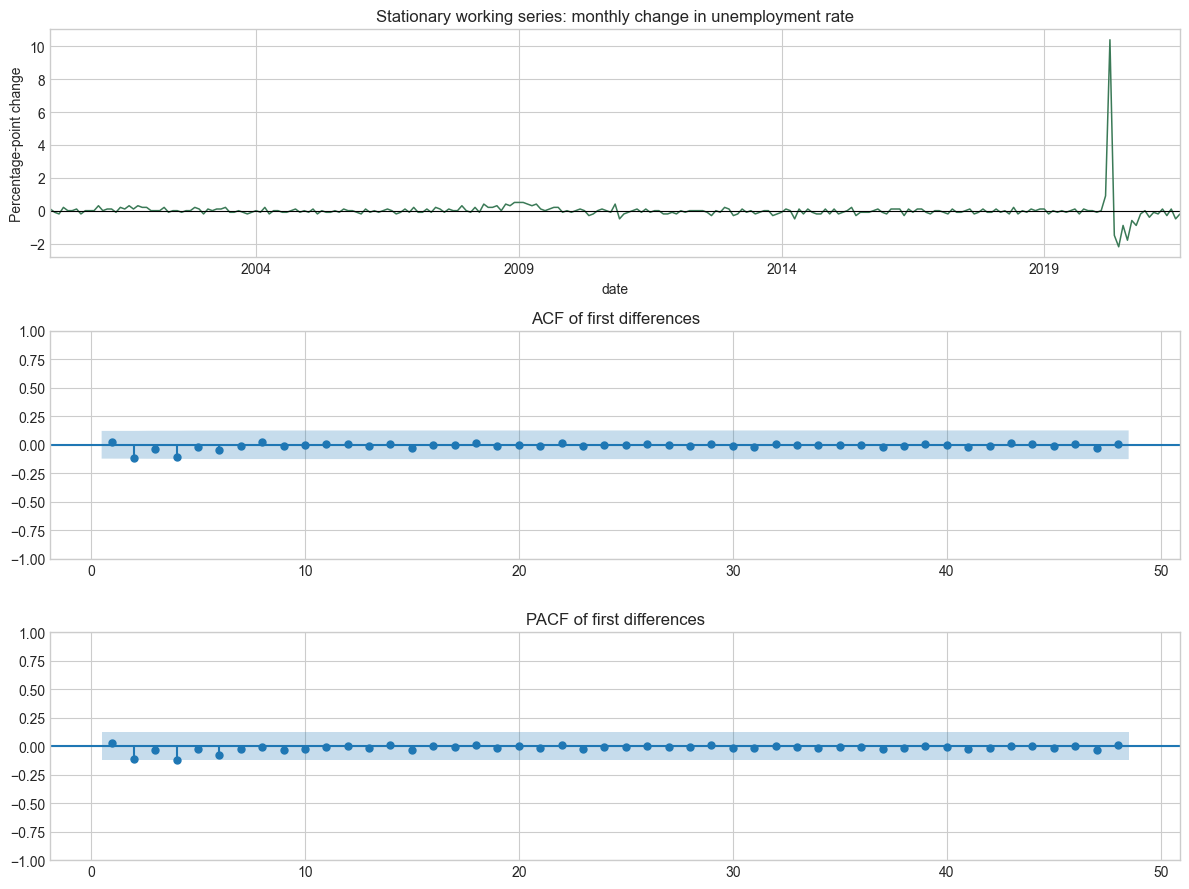

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
x.plot(ax=axes[0], color="#3b7a57", linewidth=1.1)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Stationary working series: monthly change in unemployment rate")
axes[0].set_ylabel("Percentage-point change")

plot_acf(x, lags=48, ax=axes[1], zero=False)
axes[1].set_title("ACF of first differences")

plot_pacf(x, lags=48, ax=axes[2], zero=False, method="ywm")
axes[2].set_title("PACF of first differences")

plt.tight_layout()
plt.show()

## 3. ARMA model fitting

For the stationary series $x_t$, candidate ARMA($p,q$) models are estimated by maximum likelihood using `statsmodels.tsa.arima.model.ARIMA` with integration order 0. This corresponds to the MLE-based ARMA fitting discussed in the reference text. Orders are selected by AIC/BIC over a small grid, and the last 24 months are held out for forecast evaluation.

In [28]:
h = 24
y_train = y.iloc[:-h]
y_test = y.iloc[-h:]
x_train = y_train.diff().dropna()

records = []
fits = {}
for p, q in product(range(6), range(6)):
    if p == 0 and q == 0:
        continue
    try:
        fit = ARIMA(
            x_train,
            order=(p, 0, q),
            trend="c",
            enforce_stationarity=True,
            enforce_invertibility=True,
        ).fit(method_kwargs={"warn_convergence": False})
        records.append({"p": p, "q": q, "AIC": fit.aic, "BIC": fit.bic})
        fits[(p, q)] = fit
    except Exception as err:
        records.append({"p": p, "q": q, "AIC": np.nan, "BIC": np.nan})

selection = pd.DataFrame(records).dropna().sort_values("AIC")
selected_order = tuple(selection.iloc[0][["p", "q"]].astype(int))
selected_model = fits[selected_order]

display(selection.head(10))
print(f"Selected by AIC: ARMA{selected_order} for x_t = y_t - y_(t-1)")

,p,q,AIC,BIC
13,2,2,-232.3549,-211.5974
10,1,5,-232.1560,-204.4793
22,3,5,-231.9416,-197.3457
15,2,4,-231.2876,-203.6109
16,2,5,-230.4743,-199.3380
9,1,4,-230.4296,-206.2125
14,2,3,-230.3602,-206.1431
28,4,5,-230.3296,-192.2741
32,5,3,-230.2395,-195.6437
27,4,4,-230.1386,-195.5428


Selected by AIC: ARMA(2, 2) for x_t = y_t - y_(t-1)


In [29]:
print(selected_model.summary())

param_table = selected_model.params.rename("estimate").to_frame()
param_table["std_error"] = selected_model.bse
param_table["p_value"] = selected_model.pvalues
param_table

                               SARIMAX Results                                
Dep. Variable:      unemployment_rate   No. Observations:                  235
Model:                 ARIMA(2, 0, 2)   Log Likelihood                 122.177
Date:                Wed, 22 Apr 2026   AIC                           -232.355
Time:                        17:23:10   BIC                           -211.597
Sample:                    02-01-2000   HQIC                          -223.986
                         - 08-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0019      0.027     -0.070      0.944      -0.055       0.052
ar.L1          1.5650      0.149     10.529      0.000       1.274       1.856
ar.L2         -0.6209      0.144     -4.310      0.0

,estimate,std_error,p_value
const,-0.0019,0.0273,0.9445
ar.L1,1.5650,0.1486,0.0000
ar.L2,-0.6209,0.1441,0.0000
ma.L1,-1.5734,0.1345,0.0000
ma.L2,0.7302,0.1146,0.0000
sigma2,0.0207,0.0019,0.0000


,lb_stat,lb_pvalue
12,14.1182,0.2932
24,32.9950,0.1042


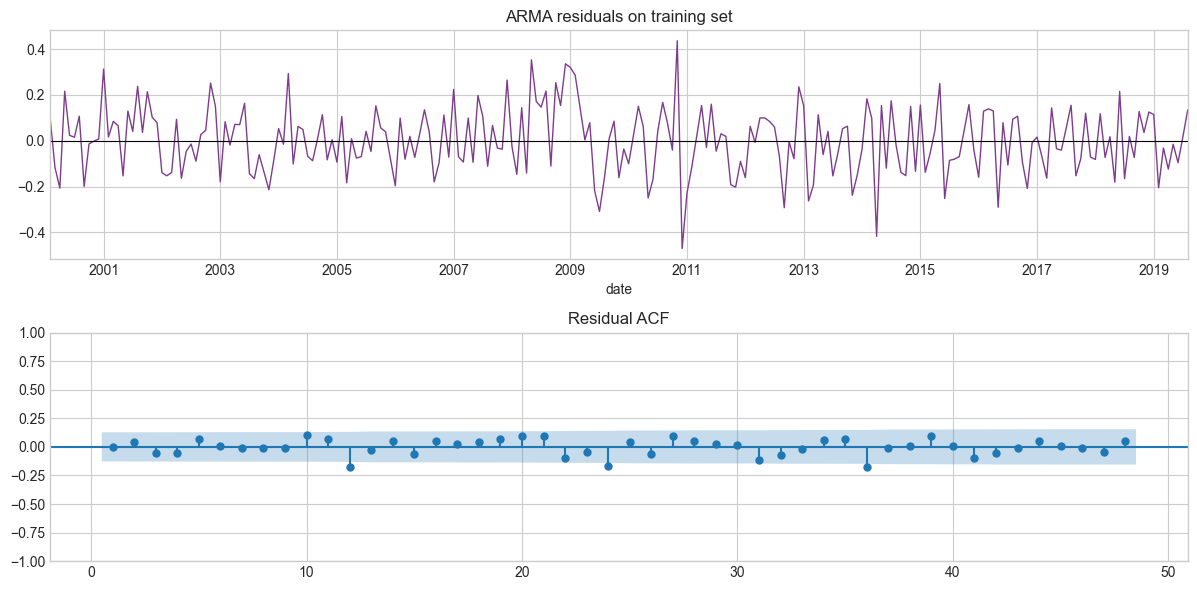

In [30]:
resid = selected_model.resid
ljung_box = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
display(ljung_box)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
resid.plot(ax=axes[0], color="#7f3c8d", linewidth=1.0)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("ARMA residuals on training set")
plot_acf(resid, lags=48, ax=axes[1], zero=False)
axes[1].set_title("Residual ACF")
plt.tight_layout()
plt.show()

## 4. Forecasting

The ARMA model forecasts the stationary differences $x_t$. Level forecasts are reconstructed by cumulative summation from the last observed training value:

$$\hat y_{T+h} = y_T + \sum_{j=1}^h \hat x_{T+j}.$$

test_start      2019-09
test_end        2021-08
RMSE             4.2790
MAE              3.0666
MAPE_percent    36.6494
dtype: object

,actual,forecast,error
date,,,
2019-09-01,3.5000,3.6564,-0.1564
2019-10-01,3.6000,3.6246,-0.0246
2019-11-01,3.6000,3.6019,-0.0019
2019-12-01,3.6000,3.5860,0.0140
2020-01-01,3.5000,3.5750,-0.0750
2020-02-01,3.5000,3.5677,-0.0677
2020-03-01,4.4000,3.5629,0.8371
2020-04-01,14.8000,3.5599,11.2401
2020-05-01,13.3000,3.5580,9.7420


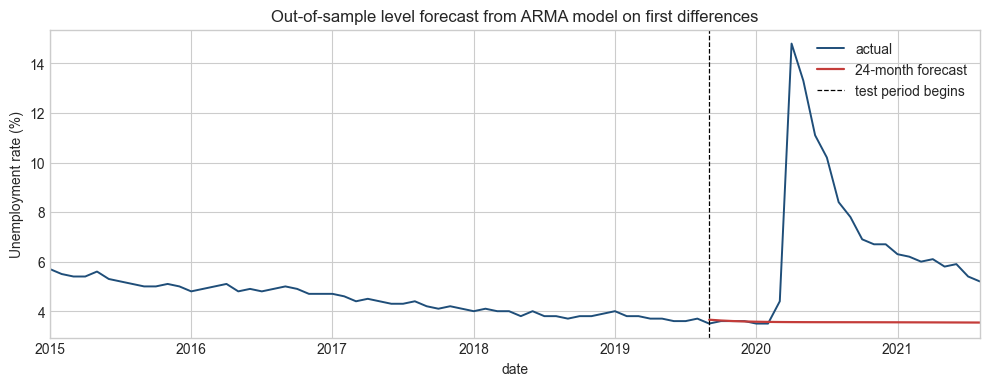

In [31]:
forecast_diff = selected_model.get_forecast(steps=h).predicted_mean
forecast_level = y_train.iloc[-1] + forecast_diff.cumsum()
forecast_level.index = y_test.index

forecast_errors = y_test - forecast_level
error_summary = pd.Series({
    "test_start": y_test.index.min().strftime("%Y-%m"),
    "test_end": y_test.index.max().strftime("%Y-%m"),
    "RMSE": np.sqrt(np.mean(forecast_errors**2)),
    "MAE": np.mean(np.abs(forecast_errors)),
    "MAPE_percent": 100 * np.mean(np.abs(forecast_errors / y_test)),
})

forecast_table = pd.DataFrame({
    "actual": y_test,
    "forecast": forecast_level,
    "error": forecast_errors,
})

display(error_summary)
display(forecast_table)

fig, ax = plt.subplots(figsize=(12, 4))
y.loc["2015":].plot(ax=ax, label="actual", color="#1f4e79", linewidth=1.4)
forecast_level.plot(ax=ax, label="24-month forecast", color="#c43c39", linewidth=1.6)
ax.axvline(y_test.index.min(), color="black", linestyle="--", linewidth=0.9, label="test period begins")
ax.set_title("Out-of-sample level forecast from ARMA model on first differences")
ax.set_ylabel("Unemployment rate (%)")
ax.legend()
plt.show()

## 5. Full-sample model for reporting

After evaluating the forecast, the same order can be refit on the complete stationary series to report parameter estimates using all available data. Because the final years include the COVID-19 labor-market shock, compare these estimates with the training-set estimates before using them for a final written report.

In [32]:
final_model = ARIMA(
    x,
    order=(selected_order[0], 0, selected_order[1]),
    trend="c",
    enforce_stationarity=True,
    enforce_invertibility=True,
).fit(method_kwargs={"warn_convergence": False})

final_params = final_model.params.rename("estimate").to_frame()
final_params["std_error"] = final_model.bse
final_params["p_value"] = final_model.pvalues

display(final_params)
display(acorr_ljungbox(final_model.resid, lags=[12, 24], return_df=True))

,estimate,std_error,p_value
const,0.0068,0.0896,0.9399
ar.L1,0.2115,0.3052,0.4884
ar.L2,0.4281,0.3199,0.1808
ma.L1,-0.2061,0.3022,0.4953
ma.L2,-0.5905,0.2766,0.0328
sigma2,0.4770,0.0160,0.0000


,lb_stat,lb_pvalue
12,1.2840,0.9999
24,1.9734,1.0000


## 6. Report-ready summary

- **Series and source.** The analyzed file is `data/US_UR.csv`, a monthly U.S. unemployment-rate series. The usable sample has 884 observations from January 1948 through August 2021 after removing blank trailing rows. If the report needs the original external source, cite the provider used to download the CSV; this variable corresponds to the standard U.S. unemployment-rate series commonly distributed by BLS/FRED.
- **Cleaning and stationarity.** The level series is persistent and has recession-related regime changes. The stationary modeling series is the first difference $x_t = y_t - y_{t-1}$, interpreted as the monthly percentage-point change in unemployment. No deterministic seasonal term is removed because monthly means differ only slightly.
- **Model estimation.** ARMA($p,q$) models for $x_t$ are estimated by maximum likelihood using `statsmodels` ARIMA with order $(p,0,q)$ and a constant. The notebook selects the order by AIC over $0 \le p,q \le 5$ excluding ARMA(0,0), then reports the coefficients, standard errors, and p-values.
- **Forecasting.** Forecasts are produced for first differences and converted back to unemployment-rate levels by cumulative summation. The 24-month test period includes the COVID-19 shock, so forecast errors are intentionally a difficult stress test of the fitted linear ARMA model.
- **Robustness and limitations.** The model captures short-run autocorrelation in unemployment changes, but large structural shocks produce heavy-tailed residuals and weak long-horizon forecasts. Extensions worth considering are intervention/outlier terms, regime-switching models, ARIMA models fitted before and after major breaks, or state-space models with time-varying components.